# 3. Feature Effects: Partial Dependence Plots (PDP) & ICE Curves

### Why This Notebook Matters
- **Permutation Importance** tells you *which* features matter globally.
- **SHAP** tells you *why* an individual prediction was made.
- **PDP & ICE** answer the strategic engineering question: **"At what exact numerical value does the model's behavior change?"**

### Core Concepts:
1. **Partial Dependence Plot (PDP):** Shows the **average marginal effect** of a feature on the target across all observations by holding all other features constant and sweeping the feature through a range of values.
2. **Individual Conditional Expectation (ICE):** Plots the response curve for **each individual sample separately**. This reveals hidden heterogeneous subgroups that an average PDP line can hide (e.g., if a feature increases risk for 50% of users but decreases it for the other 50%).
3. **2D Interaction PDP:** Evaluates how two features jointly influence the model's probability landscape.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import PartialDependenceDisplay

# 1. Create a synthetic dataset with realistic non-linear relationships
np.random.seed(42)
n_samples = 2000

# Feature 1: Account Age in months (logarithmic protective effect: churn drops early, then plateaus)
account_age = np.random.uniform(1, 60, n_samples)

# Feature 2: Monthly Charges in USD (sharp non-linear threshold: risk spikes sharply past $75)
monthly_charges = np.random.uniform(20, 120, n_samples)

# Feature 3: Support Tickets Logged (linear risk increment)
support_tickets = np.random.poisson(lam=1.5, size=n_samples)

# Latent churn log-odds with clear non-linear logic
churn_logits = (
    -0.08 * account_age + 
    np.where(monthly_charges > 75, (monthly_charges - 75) * 0.09, -0.2) + 
    0.65 * support_tickets - 
    1.2
)
churn_prob = 1 / (1 + np.exp(-churn_logits))
churn_target = (np.random.rand(n_samples) < churn_prob).astype(int)

df = pd.DataFrame({
    'Account_Age_Months': account_age,
    'Monthly_Charges': monthly_charges,
    'Support_Tickets': support_tickets,
    'Churn': churn_target
})

print(f"Dataset shape: {df.shape} | Baseline Churn Rate: {df['Churn'].mean():.2%}")
display(df.head())

Dataset shape: (2000, 4) | Baseline Churn Rate: 23.80%


,Account_Age_Months,Monthly_Charges,Support_Tickets,Churn
0,23.097867,46.170568,3,0
1,57.092144,44.697880,0,0
2,44.187643,110.625458,1,1
3,36.320851,44.954620,2,0
4,10.205100,47.194973,0,0


---
## Step 1: Train the Random Forest Classifier

We train a standard Random Forest. PDP and ICE require **no model-specific hacks**—they treat any estimator as a black box and evaluate its continuous probability outputs (`predict_proba`).

In [3]:
X = df.iloc[:,:-1]
y = df.iloc[:,-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf_model.fit(X_train, y_train)

train_acc = rf_model.score(X_train, y_train)
test_acc = rf_model.score(X_test, y_test)
print(f"Train Accuracy: {train_acc:.3f} | Test Accuracy: {test_acc:.3f}")

Train Accuracy: 0.887 | Test Accuracy: 0.840


---
## Step 2: 1D Partial Dependence Plots (PDP)

A PDP isolates a single column $X_S$. For every unique value of $X_S$, it forces that value into **all test rows**, computes the model's predicted probability across the entire test set, and calculates the average:

$$\bar{f}_S(x_S) = \frac{1}{n} \sum_{i=1}^n f(x_S, x_{C}^{(i)})$$

Where:
- $x_S$ is the feature being evaluated.
- $x_{C}^{(i)}$ represents all other features for observation $i$, left completely untouched.

d:\machine_learning_code\.venv\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 2 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


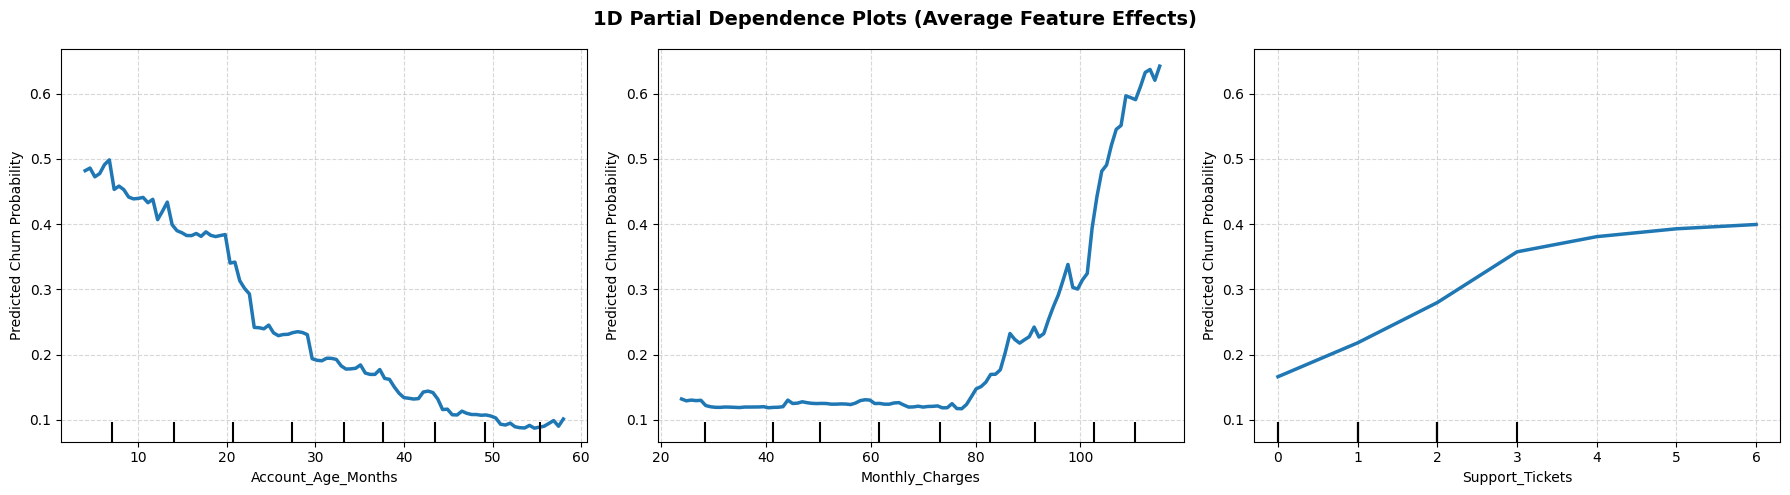

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1D Partial Dependence for all three features
display_pdp = PartialDependenceDisplay.from_estimator(
    estimator=rf_model,
    X=X_test,
    features=['Account_Age_Months', 'Monthly_Charges', 'Support_Tickets'],
    kind='average', # Standard PDP (population average curve)
    target=1,       # Probability of churn (Class 1)
    ax=ax,
    line_kw={'color': '#1f77b4', 'linewidth': 2.5}
)

for sub_ax in ax:
    sub_ax.grid(True, linestyle='--', alpha=0.5)
    sub_ax.set_ylabel("Predicted Churn Probability")

plt.suptitle("1D Partial Dependence Plots (Average Feature Effects)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 3: ICE Curves (Individual Conditional Expectation)

### The Danger of Average Curves (PDP)
If 50% of your customers churn when prices rise, but the other 50% love premium services and churn when prices drop, the average PDP line will be a flat horizontal line near `0.0`. That makes a critical feature appear useless.

**ICE solves this:**
- Instead of averaging all predictions into one line, it plots **one line per individual customer**.
- Setting `kind='both'` draws individual translucent lines (ICE) along with the thick average line (PDP).

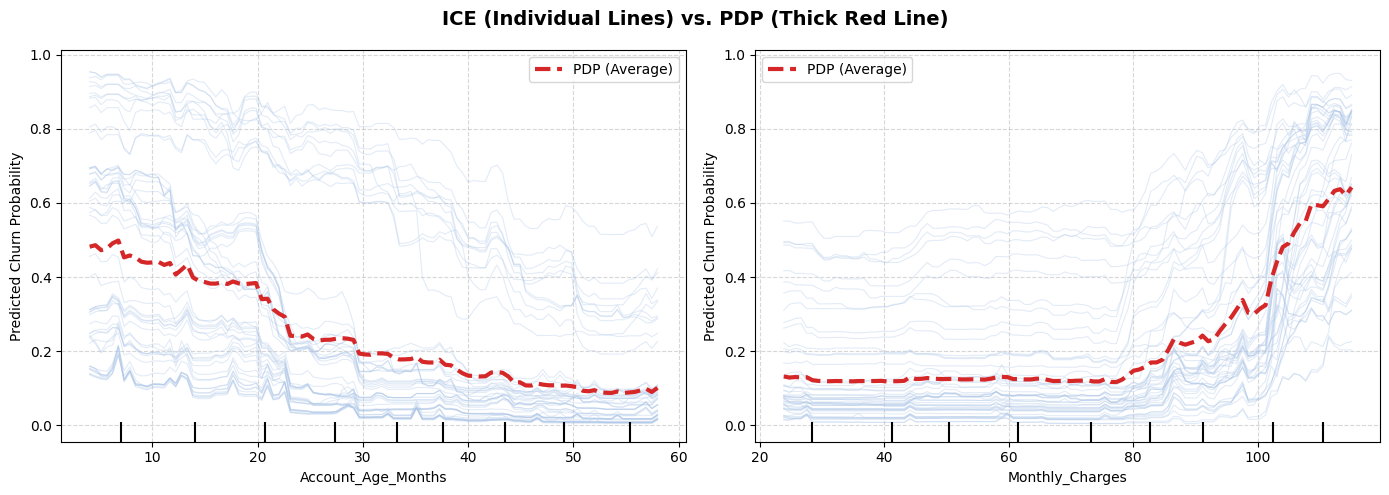

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot both ICE and PDP for the continuous features
PartialDependenceDisplay.from_estimator(
    estimator=rf_model,
    X=X_test,
    features=['Account_Age_Months', 'Monthly_Charges'],
    kind='both',       # Overlay individual ICE lines + average PDP line
    subsample=50,      # Plot 50 random test observations for visual clarity
    target=1,
    ax=ax,
    ice_lines_kw={'color': '#aec7e8', 'alpha': 0.35, 'linewidth': 0.8},
    pd_line_kw={'color': '#d62728', 'linewidth': 3.0, 'label': 'PDP (Average)'}
)

for sub_ax in ax:
    sub_ax.grid(True, linestyle='--', alpha=0.5)
    sub_ax.set_ylabel("Predicted Churn Probability")

plt.suptitle("ICE (Individual Lines) vs. PDP (Thick Red Line)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 4: 2D Partial Dependence Plots (Feature Interactions)

We evaluate how two features interact by inspecting a joint 2D contour grid. This identifies operational danger zones (e.g., combinations of low tenure and high pricing).

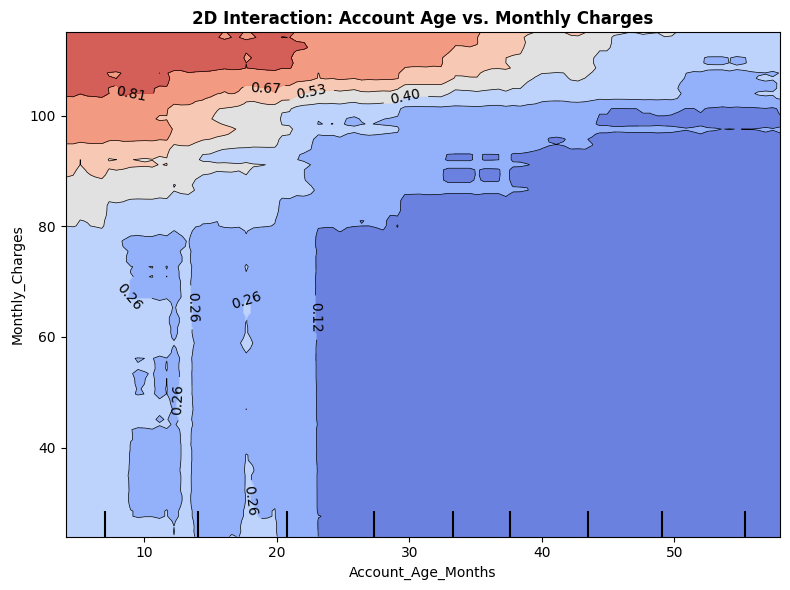

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))

PartialDependenceDisplay.from_estimator(
    estimator=rf_model,
    X=X_test,
    features=[('Account_Age_Months', 'Monthly_Charges')], # 2D tuple
    kind='average',
    target=1,
    ax=ax,
    contour_kw={'cmap': 'coolwarm', 'alpha': 0.85}
)

ax.set_title("2D Interaction: Account Age vs. Monthly Charges", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Operational Takeaways: How to Read PDP & ICE in Practice

| Feature Plot | Observation from Curve | Strategic Action / Policy |
| :--- | :--- | :--- |
| **`Account_Age_Months`** | Risk drops sharply from month 0 to 18, then completely flattens. | Focus onboarding and retention campaigns strictly during the **first 18 months**. After 18 months, tenure alone secures loyalty. |
| **`Monthly_Charges`** | Risk stays low and flat from \$20 to \$75, but surges past **\$75**. | **\$75 is the tipping point.** Price increases below \$75 carry low churn risk; increases above \$75 require high-touch incentives. |
| **`Support_Tickets`** | Monotonic, step-like increase after 2 tickets. | Set an automated threshold: **any customer with $\ge 3$ tickets** gets escalated to high-priority resolution. |
| **ICE Parallelism** | All individual ICE lines follow the exact same upward curve. | Confirms no hidden divergent subgroups; the price tipping point applies universally across accounts. |